# Multi Agents - RDB 에이전트
LangGraph를 사용하여 SQL 데이터베이스에 대한 질문에 답할 수 있는 사용자 지정 에이전트를 구현하는 시스템입니다. 

## Specialized Agent란?

**Specialized Agent**는 특정 도구나 시스템에 **특화된** Multi-Agent 패턴입니다.

### 핵심 특징

1. **도메인 전문성** (Domain Expertise)
   - 특정 도구/API/시스템에 대한 깊은 이해
   - 해당 분야의 베스트 프랙티스 적용
   
2. **도구 통합** (Tool Integration)
   - 외부 도구와의 긴밀한 연동
   - API 호출, 데이터베이스 접근 등
   
3. **맥락 인식** (Context Awareness)
   - 도구 사용 전후 맥락 파악
   - 에러 처리 및 검증

4. **단계별 추론** (Step-by-Step Reasoning)
   - 목표 달성을 위한 단계 계획
   - 도구를 언제, 어떻게 사용할지 판단

### 작동 방식

```
사용자 질문
    ↓
Agent (추론)
    ↓
필요한 도구 선택
    ↓
도구 실행 (Tool Execution)
    ↓
결과 해석
    ↓
추가 도구 필요? 
    Yes → 반복
    No → 최종 응답
```

### 이 예제가 Specialized Agent인 이유

**SQL Agent**는 Specialized Agent의 대표적인 사례입니다:

1. **특화된 도메인**: SQL 데이터베이스 전문
   - SQL 쿼리 작성 및 실행
   - 데이터베이스 스키마 이해
   - 쿼리 최적화 및 검증

2. **전문 도구 활용**: 4가지 SQL 도구 사용
   - `sql_db_list_tables`: 테이블 목록 조회
   - `sql_db_schema`: 스키마 확인
   - `sql_db_query_checker`: 쿼리 검증
   - `sql_db_query`: 쿼리 실행

3. **단계적 접근**:
   ```
   질문 → 테이블 확인 → 스키마 파악 → 쿼리 작성 → 검증 → 실행 → 결과 해석
   ```

4. **컨텍스트 활용**:
   - 이전 결과를 바탕으로 다음 도구 선택
   - 에러 발생 시 쿼리 수정

### SQL Agent의 작동 예시

**사용자 질문**: "30세 이상 사용자는 몇 명인가요?"

```
1단계: 테이블 확인
   도구: sql_db_list_tables
   결과: users, orders, products

2단계: 스키마 확인
   도구: sql_db_schema("users")
   결과: id, name, age, email

3단계: 쿼리 작성
   LLM: SELECT COUNT(*) FROM users WHERE age >= 30;

4단계: 쿼리 검증
   도구: sql_db_query_checker
   결과: 쿼리 유효함

5단계: 쿼리 실행
   도구: sql_db_query
   결과: [(42,)]

6단계: 응답 생성
   LLM: "30세 이상 사용자는 42명입니다."
```

### vs. 다른 패턴

| 패턴 | 특징 | 도구 사용 |
|------|------|----------|
| **Hierarchical** | 작업 분류 | 없음 |
| **Collaborative** | 병렬 협업 | 각자 다른 도구 |
| **Supervisor** | 순차 조율 | 간접 사용 |
| **Specialized** | 도구 전문가 | **직접 & 반복** |

### 장점

- **정확성**: 도구를 올바르게 사용
- **반복 개선**: 결과를 보고 다시 시도
- **안전성**: 검증 후 실행
- **확장성**: 새로운 도구 추가 용이

### 적합한 사용 사례

- **SQL Agent**: 데이터베이스 질의응답
- **Web Search Agent**: 실시간 정보 검색
- **Code Execution Agent**: 코드 실행 및 디버깅
- **API Agent**: 특정 API 활용
- **File System Agent**: 파일 관리
- **Calculator Agent**: 복잡한 계산


## RDB 에이전트들

| 도구 이름                  | 역할        | 주요 기능                  |
| ---------------------- | --------- | ---------------------- |
| `sql_db_list_tables`   | 테이블 목록 조회 | DB에 어떤 테이블이 있는지 확인     |
| `sql_db_schema`        | 테이블 구조 확인 | 각 테이블의 컬럼/타입/샘플 데이터 확인 |
| `sql_db_query_checker` | 쿼리 검증     | SQL 실행 전에 오류 체크        |
| `sql_db_query`         | 쿼리 실행     | 실제 쿼리 결과 조회            |


### sql_db_query
- 설명: 이 도구는 SQL 쿼리를 실행해서 실제 데이터베이스 결과를 반환합니다.
- 입력: 올바른 SQL 쿼리 (예: SELECT * FROM users WHERE age > 30;)
- 출력: 쿼리 실행 결과 (테이블 형태의 데이터)

### sql_db_schema
- 설명: 이 도구는 하나 이상의 테이블 구조(스키마)와 샘플 데이터를 보여줍니다.
- 입력: 테이블 이름을 쉼표로 구분하여 입력 (예: users, orders)
- 출력: 각 테이블의 컬럼 이름, 타입 등 스키마 정보

### sql_db_list_tables
- 설명: 데이터베이스에 존재하는 모든 테이블 목록을 반환합니다.
- 입력: 빈 문자열 ("")
- 출력: 테이블 이름들을 쉼표로 구분한 문자열

### sql_db_query_checker
- 설명: SQL 쿼리를 실행하기 전에 문법적으로 올바른지 검증합니다.
- 입력: SQL 쿼리 문자열
- 출력:
    - 쿼리가 올바르면 “문제없음”
    - 오류가 있으면 “에러 내용”

# [예제](https://docs.langchain.com/oss/python/langgraph/sql-agent)

## RDB 구축

### 1단계: 데이터 로드

In [1]:
import pandas as pd

DATA_PATH = "./data/"
df = pd.read_csv(DATA_PATH+"Titanic.csv")

print(f"(전체 데이터 수, 전체 컬럼 수)-> {df.shape}")
print(f"전체 컬럼명: {df.columns.tolist()}")

(전체 데이터 수, 전체 컬럼 수)-> (891, 12)
전체 컬럼명: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


### 2단계: Create Engine

In [2]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///titanic.db")

### 3단계: 데이터 추가 

In [3]:
df.to_sql("titanic", engine, index=False)

891

### 4단계: SQLDatabase 생성

In [4]:
from langchain_community.utilities.sql_database import SQLDatabase

db = SQLDatabase(engine=engine)

print(f"데이터베이스 종류: {db.dialect}")
print(f"테이블 리스트: {db.get_usable_table_names()}")

데이터베이스 종류: sqlite
테이블 리스트: ['titanic']


### 5단계: 데이터 조회 

In [5]:
result = db.run("SELECT * FROM titanic WHERE Age < 10;")

In [6]:
result

'[(8, 0, 3, \'Palsson, Master. Gosta Leonard\', \'male\', 2.0, 3, 1, \'349909\', 21.075, None, \'S\'), (11, 1, 3, \'Sandstrom, Miss. Marguerite Rut\', \'female\', 4.0, 1, 1, \'PP 9549\', 16.7, \'G6\', \'S\'), (17, 0, 3, \'Rice, Master. Eugene\', \'male\', 2.0, 4, 1, \'382652\', 29.125, None, \'Q\'), (25, 0, 3, \'Palsson, Miss. Torborg Danira\', \'female\', 8.0, 3, 1, \'349909\', 21.075, None, \'S\'), (44, 1, 2, \'Laroche, Miss. Simonne Marie Anne Andree\', \'female\', 3.0, 1, 2, \'SC/Paris 2123\', 41.5792, None, \'C\'), (51, 0, 3, \'Panula, Master. Juha Niilo\', \'male\', 7.0, 4, 1, \'3101295\', 39.6875, None, \'S\'), (59, 1, 2, \'West, Miss. Constance Mirium\', \'female\', 5.0, 1, 2, \'C.A. 34651\', 27.75, None, \'S\'), (64, 0, 3, \'Skoog, Master. Harald\', \'male\', 4.0, 3, 2, \'347088\', 27.9, None, \'S\'), (79, 1, 2, \'Caldwell, Master. Alden Gates\', \'male\', 0.83, 0, 2, \'248738\', 29.0, None, \'S\'), (120, 0, 3, \'Andersson, Miss. Ellis Anna Maria\', \'female\', 2.0, 4, 2, \'34

## LangGraph with SQL Agent 구축

### 1단계: LLM

In [7]:
from dotenv import load_dotenv

# 환경변수 로드
load_dotenv()

True

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### 2단계: tools

In [9]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit

toolkit = SQLDatabaseToolkit(db=db, llm=llm)

In [25]:
tools = toolkit.get_tools()

for tool in tools:
    print(f"{tool.name}: {tool.description}\n")

sql_db_query: Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.

sql_db_schema: Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3

sql_db_list_tables: Input is an empty string, output is a comma-separated list of tables in the database.

sql_db_query_checker: Use this tool to double check if your query is correct before executing it. Always use this tool before executing a query with sql_db_query!



### 3단계: State

In [40]:
from langgraph.graph.message import add_messages
from typing import Annotated
from typing_extensions import TypedDict

class State(TypedDict):
    """
    워크플로우에서 사용할 상태를 정의합니다.
    - messages: 대화 메시지들을 저장
    """
    messages: Annotated[list, add_messages]

### 4단계: Nodes

#### get_schema_node

In [ ]:
get_schema_tool = next(tool for tool in tools if tool.name == "sql_db_schema")

def get_schema_node(state: State):
    """
    데이터베이스 테이블의 스키마(구조) 정보를 조회하는 노드
    
    동작 과정:
    1. 이전 노드(call_get_schema)에서 LLM이 생성한 tool_call을 가져옴
    2. tool_call에는 조회할 테이블 이름이 포함되어 있음
    3. sql_db_schema 도구를 실행하여 테이블의 컬럼 정보와 샘플 데이터 조회
    4. 조회 결과를 ToolMessage로 반환하여 다음 노드에 전달
    """
    print("="*50)
    print("get_schema_node")
    
    # 마지막 메시지에서 tool_call 가져오기
    # LLM이 호출하려는 도구와 인자 정보가 들어있음
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]
    
    # sql_db_schema 도구 실행
    # 지정된 테이블의 스키마 정보와 샘플 데이터를 반환
    tool_message = get_schema_tool.invoke(tool_call)
    
    return {"messages": [tool_message]}

#### run_query_node

In [ ]:
run_query_tool = next(tool for tool in tools if tool.name == "sql_db_query")

def run_query_node(state: State):
    """
    실제 SQL 쿼리를 데이터베이스에 실행하는 노드
    
    동작 과정:
    1. 이전 노드(check_query)에서 검증된 SQL 쿼리를 포함한 tool_call을 가져옴
    2. sql_db_query 도구를 실행하여 실제 데이터베이스에 쿼리 실행
    3. 쿼리 실행 결과를 ToolMessage로 반환
    4. 결과는 다시 generate_query 노드로 전달되어 LLM이 최종 답변 생성
    """
    print("="*50)
    print("run_query_node")
    
    # 마지막 메시지에서 tool_call 가져오기
    # 실행할 SQL 쿼리가 tool_call의 인자에 포함되어 있음
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[0]
    
    # sql_db_query 도구 실행
    # 데이터베이스에 쿼리를 실행하고 결과를 반환
    tool_message = run_query_tool.invoke(tool_call)
    
    return {"messages": [tool_message]}

#### list_tables

In [ ]:
from langchain.messages import AIMessage

def list_tables(state: State):
    """
    데이터베이스의 모든 테이블 목록을 조회하는 노드 (워크플로우의 시작점)
    
    동작 과정:
    1. sql_db_list_tables 도구를 호출하기 위한 tool_call 객체를 직접 생성
    2. 도구를 실행하여 데이터베이스의 모든 테이블 이름을 조회
    3. 두 개의 메시지를 반환:
       - tool_call_message: AI가 도구를 호출했다는 메시지 (tool_calls 포함)
       - tool_message: 도구 실행 결과 (테이블 목록 데이터)
    
    왜 2개의 메시지를 반환하는가?
    - LangGraph의 도구 호출 패턴은 항상 쌍으로 이루어짐:
      1) AIMessage with tool_calls: "나는 이 도구를 호출할거야"
      2) ToolMessage: "도구 실행 결과는 이거야"
    - 이 패턴을 따라야 다음 노드(call_get_schema)의 LLM이 
      대화 기록을 정확하게 이해하고 적절한 응답을 생성할 수 있음
    
    다른 노드와의 차이점:
    - get_schema_node, run_query_node: 이전 노드의 LLM이 이미 tool_call_message를 
      생성했으므로 tool_message만 반환하면 됨
    - list_tables: 첫 번째 노드라서 LLM이 없으므로 tool_call_message를 
      직접 생성해야 함 (따라서 2개 반환)
    """
    print("="*50)
    print("list_tables")
    
    # sql_db_list_tables 도구를 호출하기 위한 tool_call 객체 생성
    # 이 도구는 인자가 필요 없으므로 args는 빈 딕셔너리
    tool_call = {
        "name": "sql_db_list_tables",
        "args": {},
        "id": "abc123",
        "type": "tool_call",
    }
    
    # AI가 도구를 호출했다는 메시지 생성
    # 실제 LLM이 생성한 것은 아니지만, LangGraph의 표준 패턴을 따르기 위해 필요
    tool_call_message = AIMessage(content="", tool_calls=[tool_call])

    # sql_db_list_tables 도구 실행
    # 데이터베이스에서 모든 테이블 이름을 조회
    list_tables_tool = next(tool for tool in tools if tool.name == "sql_db_list_tables")
    tool_message = list_tables_tool.invoke(tool_call)
    
    # tool_call_message와 tool_message를 쌍으로 반환
    # 다음 노드의 LLM이 "테이블 목록을 조회했고, 결과는 이거다"라고 이해할 수 있음
    return {"messages": [tool_call_message, tool_message]}

#### call_get_schema

In [ ]:
def call_get_schema(state: State):
    """
    LLM이 스키마 조회 도구를 호출하도록 하는 노드
    
    동작 과정:
    1. LLM에 sql_db_schema 도구만 제공 (tool_choice="any"로 반드시 호출하도록 강제)
    2. LLM이 현재 메시지 기록을 보고 어떤 테이블의 스키마를 조회할지 결정
    3. LLM은 조회할 테이블 이름을 인자로 포함한 tool_call을 생성
    4. 생성된 tool_call을 포함한 응답 메시지를 반환
    5. 다음 노드(get_schema_node)에서 실제 스키마 조회 수행
    
    참고: tool_choice="any"는 LLM이 반드시 도구를 호출하도록 강제함
    """
    print("="*50)
    print("call_get_schema")
    
    # LLM에 sql_db_schema 도구를 바인딩
    # tool_choice="any": LLM이 반드시 제공된 도구 중 하나를 호출하도록 강제
    llm_with_tools = llm.bind_tools([get_schema_tool], tool_choice="any")
    
    # LLM이 대화 기록을 분석하고 어떤 테이블의 스키마를 조회할지 결정
    response = llm_with_tools.invoke(state["messages"])

    return {"messages": [response]}

#### generate_query

In [67]:
generate_query_system_prompt = """
You are an agent designed to interact with a SQL database.
Given an input question, create a syntactically correct {dialect} query to run,
then look at the results of the query and return the answer. Unless the user
specifies a specific number of examples they wish to obtain, always limit your
query to at most {top_k} results.

You can order the results by a relevant column to return the most interesting
examples in the database. Never query for all the columns from a specific table,
only ask for the relevant columns given the question.

DO NOT make any DML statements (INSERT, UPDATE, DELETE, DROP etc.) to the database.
""".format(
    dialect=db.dialect,
    top_k=5,
)

In [ ]:
def generate_query(state: State):
    """
    SQL 쿼리를 생성하거나 최종 답변을 제공하는 노드
    
    동작 과정:
    1. 시스템 프롬프트를 추가하여 LLM에게 SQL 전문가 역할 부여
    2. LLM에 run_query_tool을 제공 (하지만 강제하지 않음)
    3. LLM이 대화 기록을 분석:
       - 첫 실행: 테이블 스키마를 바탕으로 SQL 쿼리 생성 및 tool_call 반환
       - 재실행(쿼리 결과 수신 후): 쿼리 결과를 해석하여 자연어 답변 생성
    4. tool_call 포함 여부에 따라 다음 노드 결정:
       - tool_call 있음: check_query로 이동 (쿼리 검증)
       - tool_call 없음: END로 이동 (최종 답변 완성)
    
    참고: tool_choice를 지정하지 않아 LLM이 자유롭게 선택 가능
    """
    print("="*50)
    print("generate_query")
    
    # SQL 에이전트 역할을 정의하는 시스템 메시지
    system_message = {
        "role": "system",
        "content": generate_query_system_prompt,
    }
    
    # LLM에 run_query_tool을 제공하되, 강제하지는 않음
    # LLM이 쿼리를 생성해야 하면 도구를 호출하고, 답변만 하면 되면 일반 텍스트 응답
    llm_with_tools = llm.bind_tools([run_query_tool])
    response = llm_with_tools.invoke([system_message] + state["messages"])

    return {"messages": [response]}

#### check_query

In [69]:
check_query_system_prompt = """
You are a SQL expert with a strong attention to detail.
Double check the {dialect} query for common mistakes, including:
- Using NOT IN with NULL values
- Using UNION when UNION ALL should have been used
- Using BETWEEN for exclusive ranges
- Data type mismatch in predicates
- Properly quoting identifiers
- Using the correct number of arguments for functions
- Casting to the correct data type
- Using the proper columns for joins

If there are any of the above mistakes, rewrite the query. If there are no mistakes,
just reproduce the original query.

You will call the appropriate tool to execute the query after running this check.
""".format(dialect=db.dialect)

In [ ]:
def check_query(state: State):
    """
    생성된 SQL 쿼리의 오류를 검증하고 수정하는 노드
    
    동작 과정:
    1. 이전 노드(generate_query)에서 생성된 SQL 쿼리를 추출
    2. SQL 전문가 역할의 시스템 프롬프트를 사용하여 쿼리 검증
    3. LLM이 일반적인 SQL 오류 패턴을 확인:
       - NOT IN과 NULL 값 사용 문제
       - UNION vs UNION ALL 선택 문제
       - BETWEEN의 범위 문제
       - 데이터 타입 불일치
       - 컬럼 및 함수 사용 오류 등
    4. 오류가 있으면 쿼리를 수정하고, 없으면 원본 쿼리 유지
    5. 검증/수정된 쿼리를 tool_call로 반환 (tool_choice="any"로 강제)
    6. 다음 노드(run_query_node)에서 실제 쿼리 실행
    """
    print("="*50)
    print("check_query")
    
    # SQL 전문가 역할을 정의하는 시스템 메시지
    system_message = {
        "role": "system",
        "content": check_query_system_prompt,
    }

    # 이전 노드에서 생성한 SQL 쿼리를 추출
    tool_call = state["messages"][-1].tool_calls[0]
    
    # 검증을 위해 쿼리를 사용자 메시지 형태로 변환
    user_message = {"role": "user", "content": tool_call["args"]["query"]}
    
    # LLM에 run_query_tool을 제공하고 반드시 호출하도록 강제
    # LLM이 쿼리를 검증/수정하여 tool_call 형태로 반환
    llm_with_tools = llm.bind_tools([run_query_tool], tool_choice="any")
    response = llm_with_tools.invoke([system_message, user_message])
    
    # 원본 메시지의 ID를 유지하여 메시지 추적 가능
    response.id = state["messages"][-1].id

    return {"messages": [response]}

### 5단계: Conditional Edge

In [ ]:
from typing import Literal
from langgraph.graph import END

def should_continue(state: State) -> Literal[END, "check_query"]:
    """
    generate_query 노드 이후의 흐름을 결정하는 조건부 엣지 함수
    
    동작 과정:
    1. generate_query 노드의 응답 메시지를 확인
    2. 메시지에 tool_calls가 있는지 검사
    3. 다음 노드 결정:
       - tool_calls 있음: "check_query"로 이동
         -> LLM이 SQL 쿼리를 생성했으므로 검증 필요
       - tool_calls 없음: END로 이동
         -> LLM이 최종 답변을 생성했으므로 워크플로우 종료
    
    워크플로우 흐름:
    - 첫 번째 실행: generate_query가 SQL 쿼리 생성 -> check_query -> run_query -> generate_query로 돌아옴
    - 두 번째 실행: generate_query가 쿼리 결과를 바탕으로 최종 답변 생성 -> END
    
    """
    messages = state["messages"]
    last_message = messages[-1]
    
    # 마지막 메시지에 tool_calls가 있는지 확인
    if not last_message.tool_calls:
        # tool_calls가 없으면 최종 답변이므로 종료
        return END
    else:
        # tool_calls가 있으면 SQL 쿼리를 검증해야 함
        return "check_query"

In [72]:
from langgraph.graph import END, START, MessagesState, StateGraph

builder = StateGraph(State)
builder.add_node("list_tables", list_tables)
builder.add_node("call_get_schema", call_get_schema)
builder.add_node("get_schema", get_schema_node)
builder.add_node("generate_query", generate_query)
builder.add_node("check_query", check_query)
builder.add_node("run_query", run_query_node)

builder.add_edge(START, "list_tables")
builder.add_edge("list_tables", "call_get_schema")
builder.add_edge("call_get_schema", "get_schema")
builder.add_edge("get_schema", "generate_query")
builder.add_conditional_edges(
    "generate_query",
    should_continue,
)
builder.add_edge("check_query", "run_query")
builder.add_edge("run_query", "generate_query")

agent = builder.compile()

### 6단계: 그래프 확인 

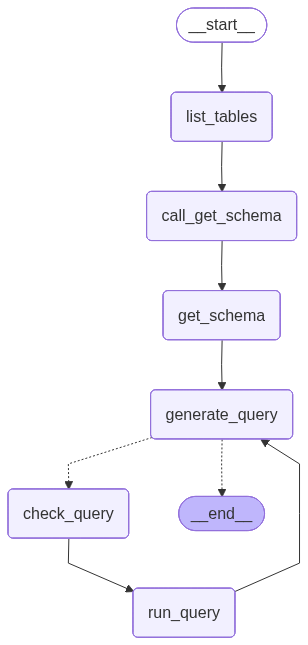

In [73]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

### 7단계: 테스트 

In [74]:
question = "생존자들의 평균 나이는?"

for step in agent.stream(
    {"messages": [{"role": "user", "content": question}]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

생존자들의 평균 나이는?
list_tables
================================= Tool Message =================================
Name: sql_db_list_tables

titanic
call_get_schema
================================== Ai Message ==================================
Tool Calls:
  sql_db_schema (call_LCrDmEmYu8ZtFpA28MIUpmd0)
 Call ID: call_LCrDmEmYu8ZtFpA28MIUpmd0
  Args:
    table_names: titanic
get_schema_node
================================= Tool Message =================================
Name: sql_db_schema


CREATE TABLE titanic (
	"PassengerId" BIGINT, 
	"Survived" BIGINT, 
	"Pclass" BIGINT, 
	"Name" TEXT, 
	"Sex" TEXT, 
	"Age" FLOAT, 
	"SibSp" BIGINT, 
	"Parch" BIGINT, 
	"Ticket" TEXT, 
	"Fare" FLOAT, 
	"Cabin" TEXT, 
	"Embarked" TEXT
)

/*
3 rows from titanic table:
PassengerId	Survived	Pclass	Name	Sex	Age	SibSp	Parch	Ticket	Fare	Cabin	Embarked
1	0	3	Braund, Mr. Owen Harris	male	22.0	1	0	A/5 21171	7.25	None	S
2	1	1	Cumings, M

In [75]:
step["messages"][-1].pretty_print()

================================== Ai Message ==================================

생존자들의 평균 나이는 약 28.34세입니다.
